In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\vic\Downloads\student_course_weekly_dataset_5000.csv")

In [3]:
df.head()

,Student_id,Course_Name,Learning_style,Preferred_learning_pace,Attention_span,Study_consistency,Focus_quality,Memory_retention,Sleep_habits,Self_regulation,...,Grade_per_course_historical_trend_%,Average_grade_per_subject_%_context_baseline,Subject_wise_interest_0_10,Time_spent_per_subject_hours_weekly,Course_difficulty_perception_0_10,Platform_login_frequency_hours_weekly_Optional,Course_interaction_logs_Quiz_Attempt_0_5_Optional,Course_interaction_discussion_posts_Yes_No_Optional,Course_interaction_Video_watched_status_Optional,Course_Specific_Performance_pct_Target
0,SID100000,Chemistry,Visual,Medium pace,Moderate,Moderate,Low,Medium,Healthy,Good,...,68.1,80.8,7.8,3.1,5.3,3.1,NaN,NaN,Incomplete,50.0
1,SID100001,Agricultural Science,Kinesthetic,Slow learner,Short,Very High,High,Medium,Poor,Excellent,...,65.6,53.0,7.0,2.6,4.8,NaN,1.0,No,Incomplete,52.4
2,SID100002,Statistics,Visual,Medium pace,Good,High,High,Medium,Healthy,Low,...,68.6,50.2,4.8,3.1,6.5,1.7,NaN,NaN,Incomplete,48.9
3,SID100003,Business Studies,Kinesthetic,Fast learner,Moderate,Very High,High,Medium,Poor,Good,...,72.7,59.7,5.9,1.9,3.3,7.7,1.0,No,Up-to-date,55.7
4,SID100004,History,Visual,Slow learner,Moderate,Inconsistent,High,Medium,Healthy,Developing,...,70.3,62.8,6.7,6.8,3.5,3.8,0.0,No,Up-to-date,44.8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Student_id                                           5000 non-null   object 
 1   Course_Name                                          5000 non-null   object 
 2   Learning_style                                       5000 non-null   object 
 3   Preferred_learning_pace                              5000 non-null   object 
 4   Attention_span                                       5000 non-null   object 
 5   Study_consistency                                    5000 non-null   object 
 6   Focus_quality                                        5000 non-null   object 
 7   Memory_retention                                     5000 non-null   object 
 8   Sleep_habits                                         5000 non-null  

In [5]:
df.shape

(5000, 31)

In [6]:
cols_to_int = [
    "Subject_wise_interest_0_10",
    "Time_spent_per_subject_hours_weekly",
    "Course_difficulty_perception_0_10",
    "Platform_login_frequency_hours_weekly_Optional"
]

# Convert to integer where possible (keeping NaN where they exist)
for col in cols_to_int:
    df[col] = df[col].apply(lambda x: int(round(x)) if pd.notnull(x) else np.nan)

In [7]:
df.head()

,Student_id,Course_Name,Learning_style,Preferred_learning_pace,Attention_span,Study_consistency,Focus_quality,Memory_retention,Sleep_habits,Self_regulation,...,Grade_per_course_historical_trend_%,Average_grade_per_subject_%_context_baseline,Subject_wise_interest_0_10,Time_spent_per_subject_hours_weekly,Course_difficulty_perception_0_10,Platform_login_frequency_hours_weekly_Optional,Course_interaction_logs_Quiz_Attempt_0_5_Optional,Course_interaction_discussion_posts_Yes_No_Optional,Course_interaction_Video_watched_status_Optional,Course_Specific_Performance_pct_Target
0,SID100000,Chemistry,Visual,Medium pace,Moderate,Moderate,Low,Medium,Healthy,Good,...,68.1,80.8,8,3,5,3.0,NaN,NaN,Incomplete,50.0
1,SID100001,Agricultural Science,Kinesthetic,Slow learner,Short,Very High,High,Medium,Poor,Excellent,...,65.6,53.0,7,3,5,NaN,1.0,No,Incomplete,52.4
2,SID100002,Statistics,Visual,Medium pace,Good,High,High,Medium,Healthy,Low,...,68.6,50.2,5,3,6,2.0,NaN,NaN,Incomplete,48.9
3,SID100003,Business Studies,Kinesthetic,Fast learner,Moderate,Very High,High,Medium,Poor,Good,...,72.7,59.7,6,2,3,8.0,1.0,No,Up-to-date,55.7
4,SID100004,History,Visual,Slow learner,Moderate,Inconsistent,High,Medium,Healthy,Developing,...,70.3,62.8,7,7,4,4.0,0.0,No,Up-to-date,44.8


In [8]:
df.isna().sum()

Student_id                                                0
Course_Name                                               0
Learning_style                                            0
Preferred_learning_pace                                   0
Attention_span                                            0
Study_consistency                                         0
Focus_quality                                             0
Memory_retention                                          0
Sleep_habits                                              0
Self_regulation                                           0
Goal_setting_behavior                                     0
Motivation_type                                           0
Stress_level                                              0
Confidence_level                                          0
Growth_mindset                                            0
Grit                                                      0
Test_quiz_scores_weekly_0_20            

In [9]:
categorical_cols = [
    'Course_Name', 'Learning_style', 'Preferred_learning_pace',
    'Attention_span', 'Study_consistency', 'Focus_quality',
    'Memory_retention', 'Sleep_habits', 'Self_regulation',
    'Goal_setting_behavior', 'Motivation_type', 'Stress_level',
    'Confidence_level', 'Growth_mindset', 'Grit',
    'Course_interaction_discussion_posts_Yes_No_Optional',
    'Course_interaction_Video_watched_status_Optional'
]

numerical_cols = [
    'Test_quiz_scores_weekly_0_20',
    'Assignment_completion_rate_weekly_%',
    'Class_attendance_weekly_%',
    'Homework_accuracy_weekly_%_Optional',
    'Grade_per_course_current_%',
    'Grade_per_course_historical_trend_%',
    'Average_grade_per_subject_%_context_baseline',
    'Subject_wise_interest_0_10',
    'Time_spent_per_subject_hours_weekly',
    'Course_difficulty_perception_0_10',
    'Platform_login_frequency_hours_weekly_Optional',
    'Course_interaction_logs_Quiz_Attempt_0_5_Optional'
]

target_col = 'Course_Specific_Performance_pct_Target'

In [10]:
# Fill only categorical NaNs with "Optional"
df[categorical_cols] = df[categorical_cols].fillna("Optional")

# Fill numeric NaNs with 0 (or the column mean if you prefer)
df[numerical_cols] = df[numerical_cols].apply(
    lambda x: x.fillna(x.mean()) if x.dtype != "O" else x
)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout

# 1. Tokenization (each categorical column as a token string)
categorical_texts = df[categorical_cols].astype(str).agg(" ".join, axis=1)

# 2. Tokenize entire sequence of categorical data
text_vectorizer = layers.TextVectorization(
    output_mode="int", output_sequence_length=len(categorical_cols)
)
text_vectorizer.adapt(categorical_texts)
vocab_size = len(text_vectorizer.get_vocabulary())

# 3. Numerical normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Split
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    categorical_texts, df[numerical_cols], df[target_col], test_size=0.2, random_state=42
)

In [12]:
# Transformer Encoder block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)  # project back to original embedding size
    return x + res

# Text input (categorical sequence)
text_input = layers.Input(shape=(None,), dtype=tf.int32, name="categorical_sequence")
x = layers.Embedding(input_dim=vocab_size, output_dim=64)(text_input)

# Add a few transformer blocks
for _ in range(2):
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)

x = layers.GlobalAveragePooling1D()(x)

# Numerical input
num_input = layers.Input(shape=(len(numerical_cols),), name="numerical_input")

# Combine both
combined = layers.Concatenate()([x, num_input])
combined = Dense(128, activation="relu")(combined)
combined = Dropout(0.3)(combined)
combined = Dense(64, activation="relu")(combined)
output = Dense(1, activation="linear")(combined)

model = Model(inputs=[text_input, num_input], outputs=output)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_sequen… │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 64)  │      4,096 │ categorical_sequ… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 64)  │        128 │ embedding[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 64)  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, None, 64)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 64)  │          0 │ dropout_1[0][0],  │
│                     │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, None, 128) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None, 64)  │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 64)  │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 64)  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, None, 64)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 64)  │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, None, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, None, 128) │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, None, 64)  │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 188,673 (737.00 KB)

 Trainable params: 188,673 (737.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
X_train_seq = text_vectorizer(X_train_text)
X_test_seq = text_vectorizer(X_test_text)

history = model.fit(
    {"categorical_sequence": X_train_seq, "numerical_input": X_train_num},
    y_train,
    validation_data=({"categorical_sequence": X_test_seq, "numerical_input": X_test_num}, y_test),
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 105ms/step - loss: 350.4202 - mae: 13.1692 - val_loss: 62.5643 - val_mae: 6.3271
Epoch 2/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 80.5692 - mae: 7.1769 - val_loss: 56.8921 - val_mae: 6.0242
Epoch 3/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 69.3027 - mae: 6.6649 - val_loss: 55.3806 - val_mae: 5.9623
Epoch 4/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 61.7608 - mae: 6.3169 - val_loss: 44.4596 - val_mae: 5.3500
Epoch 5/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 56.3676 - mae: 6.0139 - val_loss: 42.1101 - val_mae: 5.2252
Epoch 6/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 53.5706 - mae: 5.8520 - val_loss: 40.2787 - val_mae: 5.1001
Epoch 7/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 51.8828 - mae: 5.7800 - val_loss: 41.4692 - val_mae: 5.1442
Epoch 8/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 51.7634 - mae: 5.8304 - val_loss: 47.7019 - val_mae: 5.5245


In [14]:
loss, mae = model.evaluate(
    {"categorical_sequence": X_test_seq, "numerical_input": X_test_num}, y_test
)
print(f"Test MAE: {mae:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 47.7019 - mae: 5.5245
Test MAE: 5.525


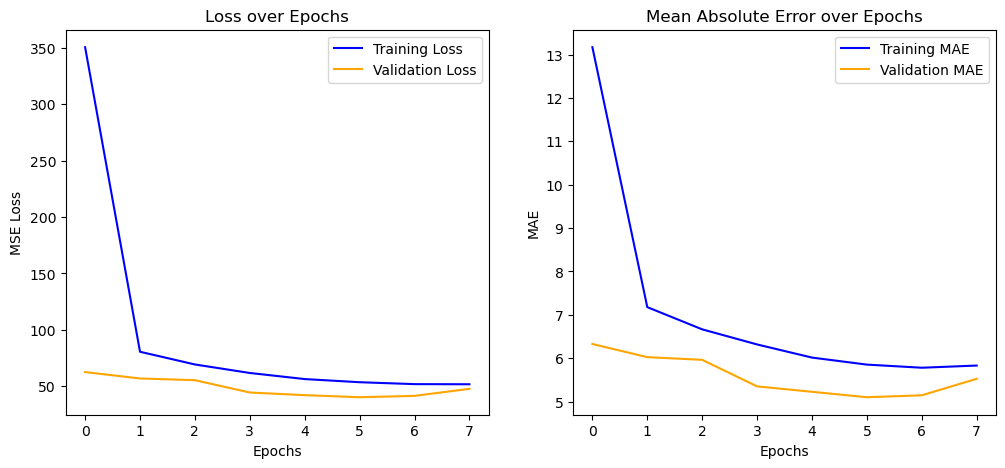

In [15]:
import matplotlib.pyplot as plt

# Extract history
history_dict = history.history

plt.figure(figsize=(12, 5))

# --- Loss ---
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Training Loss', color='blue')
plt.plot(history_dict['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

# --- MAE ---
plt.subplot(1, 2, 2)
plt.plot(history_dict['mae'], label='Training MAE', color='blue')
plt.plot(history_dict['val_mae'], label='Validation MAE', color='orange')
plt.title('Mean Absolute Error over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [16]:
test_loss, test_mae = model.evaluate(
    {"categorical_sequence": X_test_seq, "numerical_input": X_test_num}, 
    y_test, 
    verbose=0
)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test Loss (MSE): 47.7019
Test MAE: 5.5245


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step  


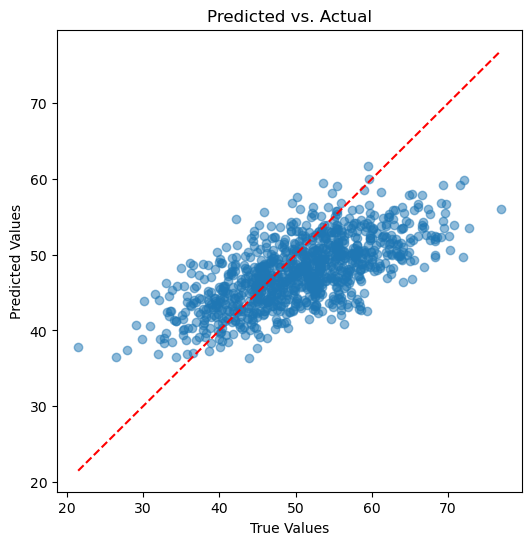

In [17]:
import numpy as np

y_pred = model.predict(
    {"categorical_sequence": X_test_seq, "numerical_input": X_test_num}
)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs. Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [18]:
def predict_course_performance(new_data: dict):
    """
    Predicts Course_Specific_Performance_pct_Target for a single student or batch.
    new_data: dict or list of dicts representing the student(s)
    """
    # Convert to DataFrame
    if isinstance(new_data, dict):
        new_df = pd.DataFrame([new_data])
    else:
        new_df = pd.DataFrame(new_data)

    # Ensure all categorical columns exist
    for col in categorical_cols:
        if col not in new_df.columns:
            new_df[col] = "Unknown"  # or some default category

    # Ensure all numerical columns exist
    for col in numerical_cols:
        if col not in new_df.columns:
            new_df[col] = 0.0  # or np.nan

    # 1️⃣ Convert categorical columns to text sequence
    cat_text = new_df[categorical_cols].astype(str).agg(" ".join, axis=1)
    cat_seq = text_vectorizer(cat_text)

    # 2️⃣ Normalize numeric columns using training scaler
    num_data = scaler.transform(new_df[numerical_cols])

    # 3️⃣ Predict
    prediction = model.predict({"categorical_sequence": cat_seq, "numerical_input": num_data})
    return prediction.flatten()

In [19]:
new_student = {
    "Learning_style": "Visual",
    "Preferred_learning_pace": "Moderate",
    "Attention_span": "High",
    "Study_consistency": "Regular",
    "Focus_quality": "Excellent",
    "Memory_retention": "Strong",
    "Sleep_habits": "Good",
    "Self_regulation": "High",
    "Goal_setting_behavior": "Consistent",
    "Motivation_type": "Intrinsic",
    "Stress_level": "Low",
    "Confidence_level": "High",
    "Growth_mindset": "Strong",
    "Grit": "High",
    "Test_quiz_scores_weekly_0_20": 18,
    "Assignment_completion_rate_weekly_%": 95,
    "Class_attendance_weekly_%": 97,
    "Homework_accuracy_weekly_%_Optional": 92,
    "Grade_per_course_current_%": 88,
    "Grade_per_course_historical_trend_%": 85,
    "Average_grade_per_subject_%_context_baseline": 82,
    "Subject_wise_interest_0_10": 9,
    "Time_spent_per_subject_hours_weekly": 12,
    "Course_difficulty_perception_0_10": 4,
    "Platform_login_frequency_hours_weekly_Optional": 10,
    "Course_interaction_logs_Quiz_Attempt_0_5_Optional": 4,
    "Course_interaction_discussion_posts_Yes_No_Optional": "Yes",
    "Course_interaction_Video_watched_status_Optional": "Watched"
}

predicted_score = predict_course_performance(new_student)
print(f"Predicted Course Performance: {predicted_score[0]:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Predicted Course Performance: 68.76%


In [20]:
def predict_course_performance_flexible(new_data: dict):
    """
    Predicts Course_Specific_Performance_pct_Target for a single student or batch.
    Automatically fills missing categorical/numerical columns with defaults.
    
    new_data: dict or list of dicts representing the student(s)
    """
    import pandas as pd
    import numpy as np

    # Convert to DataFrame
    if isinstance(new_data, dict):
        new_df = pd.DataFrame([new_data])
    else:
        new_df = pd.DataFrame(new_data)
    
    # Fill missing categorical columns with "Unknown"
    for col in categorical_cols:
        if col not in new_df.columns:
            new_df[col] = "Unknown"
    
    # Fill missing numerical columns with 0.0
    for col in numerical_cols:
        if col not in new_df.columns:
            new_df[col] = 0.0

    # Ensure correct column order
    new_df = new_df[categorical_cols + numerical_cols]

    # Convert categorical columns to text sequence
    cat_text = new_df[categorical_cols].astype(str).agg(" ".join, axis=1)
    cat_seq_tensor = text_vectorizer(cat_text)
    cat_seq = cat_seq_tensor.numpy()  # Convert to NumPy array

    # Normalize numerical columns using training scaler
    num_data = scaler.transform(new_df[numerical_cols])

    # Predict
    prediction = model.predict({"categorical_sequence": cat_seq, "numerical_input": num_data})
    return prediction.flatten()


In [21]:
new_student = {
    "Learning_style": "Visual",
    "Preferred_learning_pace": "Moderate",
    "Attention_span": "High",
    "Study_consistency": "Regular",
    "Focus_quality": "Excellent",
    "Memory_retention": "Strong",
    "Sleep_habits": "Good",
    "Self_regulation": "High",
    "Goal_setting_behavior": "Consistent",
    "Motivation_type": "Intrinsic",
    "Stress_level": "Low",
    "Confidence_level": "High",
    "Growth_mindset": "Strong",
    "Grit": "High",
    "Test_quiz_scores_weekly_0_20": 18,
    "Assignment_completion_rate_weekly_%": 95,
    "Class_attendance_weekly_%": 97,
    "Homework_accuracy_weekly_%_Optional": 92,
    "Grade_per_course_current_%": 88,
    "Grade_per_course_historical_trend_%": 85,
    "Average_grade_per_subject_%_context_baseline": 82,
    "Subject_wise_interest_0_10": 9,
    "Time_spent_per_subject_hours_weekly": 12,
    "Course_difficulty_perception_0_10": 4,
    "Platform_login_frequency_hours_weekly_Optional": 10,
    "Course_interaction_logs_Quiz_Attempt_0_5_Optional": 4,
    "Course_interaction_discussion_posts_Yes_No_Optional": "Yes",
    "Course_interaction_Video_watched_status_Optional": "Watched"
}

predicted_score = predict_course_performance_flexible(new_student)
print(f"Predicted Course Performance: {predicted_score[0]:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Predicted Course Performance: 68.76%


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def predict_multiple_courses(student_features: dict, course_data: list):
    """
    Predicts course performance for a student across multiple courses.
    
    Parameters:
        student_features: dict with all constant student-level features (behavior, learning style, etc.)
        course_data: list of dicts, each containing course-specific features (Course_Name, Grade_per_course_current_%, etc.)
    
    Returns:
        course_predictions_df: DataFrame with course names and predicted performance
        Displays a bar chart with predictions and average
    """
    predictions = []
    course_names = []
    
    for course in course_data:
        # Merge student features with course-specific features
        combined_input = {**student_features, **course}
        # Predict using flexible prediction function
        pred = predict_course_performance(combined_input)[0]  # single value
        predictions.append(pred)
        course_names.append(course.get("Course_Name", f"Course_{len(predictions)}"))
    
    # Build DataFrame
    course_predictions_df = pd.DataFrame({
        "Course_Name": course_names,
        "Predicted_Performance_pct": predictions
    })
    
    # Calculate average
    avg_perf = np.mean(predictions)
    
    # Plot bar chart
    plt.figure(figsize=(12, 10))
    plt.bar(course_names, predictions, color=("blue", "orange", "green", "pink", "yellow"))
    plt.axhline(y=avg_perf, color="red", linestyle="--", label=f"Average: {avg_perf:.2f}%")
    plt.ylabel("Predicted Performance (%)")
    plt.title("Predicted Course Performance per Course")
    plt.xticks(rotation=45)
    plt.legend()
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()
    
    return course_predictions_df

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


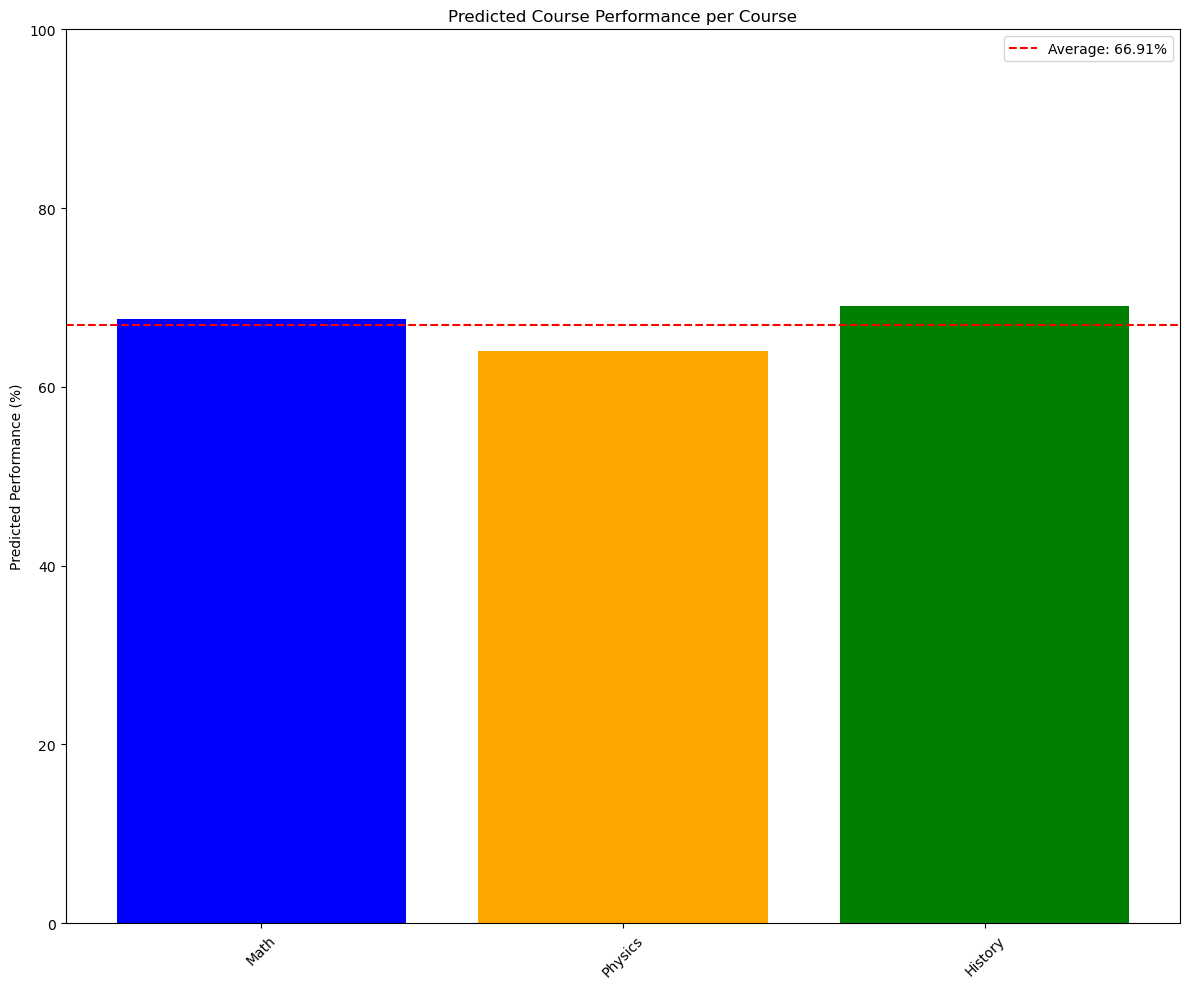

  Course_Name  Predicted_Performance_pct
0        Math                  67.636986
1     Physics                  64.017540
2     History                  69.065681


In [29]:
# Student-level features (constant across courses)
student_features = {
    "Learning_style": "Visual",
    "Preferred_learning_pace": "Moderate",
    "Attention_span": "High",
    "Study_consistency": "Regular",
    "Focus_quality": "Excellent",
    "Memory_retention": "Strong",
    "Sleep_habits": "Good",
    "Self_regulation": "High",
    "Goal_setting_behavior": "Consistent",
    "Motivation_type": "Intrinsic",
    "Stress_level": "Low",
    "Confidence_level": "High",
    "Growth_mindset": "Strong",
    "Grit": "High",
    "Test_quiz_scores_weekly_0_20": 18,
   # "Assignment_completion_rate_weekly_%": 95,
   # "Class_attendance_weekly_%": 97,
    "Homework_accuracy_weekly_%_Optional": 92,
   # "Grade_per_course_current_%": 88,
    "Grade_per_course_historical_trend_%": 85,
    "Average_grade_per_subject_%_context_baseline": 82,
    "Subject_wise_interest_0_10": 9,
    "Time_spent_per_subject_hours_weekly": 12,
    "Course_difficulty_perception_0_10": 4,
    "Platform_login_frequency_hours_weekly_Optional": 10,
    "Course_interaction_logs_Quiz_Attempt_0_5_Optional": 4,
    "Course_interaction_discussion_posts_Yes_No_Optional": "Yes",
    "Course_interaction_Video_watched_status_Optional": "Watched"
    
}

# List of courses with course-specific features
courses = [
    {"Course_Name": "Math", "Grade_per_course_current_%": 85, "Class_attendance_weekly_%": 90, "Assignment_completion_rate_weekly_%": 95},
    {"Course_Name": "Physics", "Grade_per_course_current_%": 78, "Class_attendance_weekly_%": 85, "Assignment_completion_rate_weekly_%": 80},
    {"Course_Name": "History", "Grade_per_course_current_%": 92, "Class_attendance_weekly_%": 95, "Assignment_completion_rate_weekly_%": 100},
]

# Run prediction
df_predictions = predict_multiple_courses(student_features, courses)
print(df_predictions)


In [31]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.models import Model
from tensorflow.keras import Input


In [34]:
#Save the full model
model.save("course_performance_model.keras")

In [35]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import TextVectorization

# Wrap it
text_input = Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(text_input)
vectorizer_model = Model(text_input, x)

# Save the wrapper model
vectorizer_model.save("text_vectorizer_model.keras")


In [36]:
import joblib

joblib.dump(scaler, "numerical_scaler.pkl")

['numerical_scaler.pkl']

In [37]:
import json

preprocessing_info = {
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols,
    "categorical_default": "Unknown",
    "numerical_default": 0.0
}

with open("preprocessing_info.json", "w") as f:
    json.dump(preprocessing_info, f)